In [282]:
# import system libraries
import logging
import sys, copy
# import scientific libraries
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

from scipy.interpolate import InterpolatedUnivariateSpline as spline
import h5py
import pandas as pd
# import data analysis libraries
from ldc.waveform.lisabeta import FastBHB
import lisabeta.lisa.lisa as lisa

from ldc.lisa.noise import AnalyticNoise, get_noise_model
from chainconsumer import Chain, ChainConsumer, make_sample, Truth
import lisaconstants
# import sampler libraries
from eryn.ensemble import EnsembleSampler
from eryn.state import State
from eryn.prior import uniform_dist, ProbDistContainer

from lisabeta.lisa.lisa import EvaluateTDIFreqseries
import lisabeta.tools.pyspline as pyspline
import lisabeta.lisa.lisatools as lisatools
import lisabeta.tools.pytools as pytools
from ldc.common import tools
from ldc.waveform.waveform import HpHc
import scipy.signal



mpl.rcParams.update(mpl.rcParamsDefault)

# Set up injection and find noiseless Afull and Efull. Set up Npsd, timing, and frequencies

In [283]:
#imports all dependencies and homebrewed functions
import LISA_TTL_Functions as foc

In [ ]:
filename = '/Users/corinnekomlodi/Desktop/LDC2_sangria_training_v2.h5'
catpath = 'sky/mbhb/cat'
pMBHB_ldc = foc.sangria_source(filename, catpath, 2)
print(pMBHB_ldc)
pMBHB_ldc['Distance'] = pMBHB_ldc['Distance']*10
print(pMBHB_ldc)

{np.str_('EclipticLatitude'): np.float64(0.6360283643790571), np.str_('EclipticLongitude'): np.float64(0.7791590074474859), np.str_('PolarAngleOfSpin1'): np.float64(2.3320268835068347), np.str_('PolarAngleOfSpin2'): np.float64(2.0654433523386597), np.str_('Spin1'): np.float64(0.574122), np.str_('Spin2'): np.float64(0.592671), np.str_('Mass1'): np.float64(1773562.66072), np.str_('Mass2'): np.float64(1083355.70016), np.str_('CoalescenceTime'): np.float64(11167843.442016248), np.str_('PhaseAtCoalescence'): np.float64(2.311126736432254), np.str_('InitialPolarAngleL'): np.float64(0.23280216394831457), np.str_('InitialAzimuthalAngleL'): np.float64(3.7984106562455566), np.str_('Redshift'): np.float64(6.03496), np.str_('Distance'): np.float64(59472.23759169399), np.str_('ObservationDuration'): np.float64(31558149.763545603), np.str_('Cadence'): np.float64(3.0)}
{np.str_('EclipticLatitude'): np.float64(0.6360283643790571), np.str_('EclipticLongitude'): np.float64(0.7791590074474859), np.str_('P

In [285]:
#set up the injection
'''
pMBHB_ldc = {'EclipticLatitude': -0.30300442294174235,
 'EclipticLongitude': 1.2925183861048521,
 'PolarAngleOfSpin1': 1.2031361791056812,
 'PolarAngleOfSpin2': 2.097303543065685,
 'Spin1': 0.747377,
 'Spin2': 0.8388,
 'Mass1': 1323277.47932, #original 1323277.47932
 'Mass2': 612485.5060299999, #original 612485.5060299999
 'CoalescenceTime': 11526944.921879262,
 'PhaseAtCoalescence': 1.2201968860015653,
 'InitialPolarAngleL': 2.6919824500032945,
 'InitialAzimuthalAngleL': 1.808398497592109,
 'Redshift': 1.73941,
 'Distance': 134700.983559, #13470.983559 original
 'ObservationDuration': 31558149.763545603, # 1.0007023643945205 years
 'Cadence': 3.0}
 '''

"\npMBHB_ldc = {'EclipticLatitude': -0.30300442294174235,\n 'EclipticLongitude': 1.2925183861048521,\n 'PolarAngleOfSpin1': 1.2031361791056812,\n 'PolarAngleOfSpin2': 2.097303543065685,\n 'Spin1': 0.747377,\n 'Spin2': 0.8388,\n 'Mass1': 1323277.47932, #original 1323277.47932\n 'Mass2': 612485.5060299999, #original 612485.5060299999\n 'CoalescenceTime': 11526944.921879262,\n 'PhaseAtCoalescence': 1.2201968860015653,\n 'InitialPolarAngleL': 2.6919824500032945,\n 'InitialAzimuthalAngleL': 1.808398497592109,\n 'Redshift': 1.73941,\n 'Distance': 134700.983559, #13470.983559 original\n 'ObservationDuration': 31558149.763545603, # 1.0007023643945205 years\n 'Cadence': 3.0}\n "

snr = 22295 for distance 1347.983559 \
snr = 223 for distance 134700 \
snr = 12021 for distance 2500 \
snr = 2230 for distance 13470 \
snr = 7026 for mass x10 distance 2500 \
snr = 1303 for mass x10 distance 13470 \
snr = 130 for mass x10 distance 134700 \
snr = 2096 for mass x.1 distance 2500 \
snr = 389 for mass x0.1 distance 13470 \
snr = 38 for mass x0.1 distance 134700

In [ ]:
save_name = 'sangria_index_2_distancex10'

still need to run:

In [287]:
#establish t_min, max, separation and number of samples
t_min = 0
t_max = pMBHB_ldc["CoalescenceTime"]+1000
dt = 0.25
df = 1/t_max

t = np.arange(t_min, t_max, dt)

In [288]:
#set up the injection in lisabeta terms
FBH = FastBHB("MBHB", T=t_max, delta_t=dt, approx="IMRPhenomHM")
pMBHB = FBH.rename_as_lisabeta(pMBHB_ldc)

pMBHB['psi'] += np.pi
pMBHB['phi'] -= np.pi
print(pMBHB)

{'beta': np.float64(0.6360283643790571), 'lambda': np.float64(0.7791590074474859), 'chi1': np.float64(-0.39603674747649886), 'chi2': np.float64(-0.28135337880446776), 'm1': np.float64(1773562.66072), 'm2': np.float64(1083355.70016), 'Deltat': np.float64(11167843.442016248), 'phi': np.float64(-0.830465917157539), 'dist': 2500, 'psi': np.float64(4.743022705428948), 'inc': np.float64(1.9755311514567404)}


In [289]:
#background settings
waveform_params_smbh = {
    "minf": 1e-5,
    "maxf": 1,
    "t0": 0.0,
    "timetomerger_max": 1.0,
    "tmax": 1.0,
    "TDI": "TDI2AET",
    "LISAconst": "Proposal",
    "responseapprox": "full",
    "frozenLISA": False,
    "TDIrescaled": False,
    "modes": None,
    # Waveform approximant and set of harmonics to use 
    "approximant": "IMRPhenomHM"
}

# Standard frequency vector between min and max [1e-5,1] with no zero allowed

In [ ]:
#Fvec for interpolation
fmin = .01
fmax = 0.1
ndata = int(t_max/dt)
df = 1/t_max

# Get the full frequencies
if (ndata % 2)==0:              # Get the number of frequencies
    nfft = int((ndata/2)+1)
else:
    nfft = int((ndata+1)/2)

F = df*nfft                 # make the positive frequency vector
fvec = np.arange(0, F, df)

# Get the frequencies of interest
f_inds = np.where(np.logical_and(fvec >= fmin, fvec < fmax))
fvec = fvec[f_inds]
fvec = fvec[fvec>0]
print(len(fvec))

11168732


In [291]:
#fvec_coarse = fvec[::8000]  
#print(len(fvec_coarse))

In [292]:
#downsample fvec
if len(fvec) != 1441:
    fvec = fvec[::8000]  
    fvec = np.ascontiguousarray(fvec)
else:
    pass

print(len(fvec))

1397


In [293]:
df = fvec[1]-fvec[0]
n0 = 1 #mask number
n1 = 1

## Generating A/E full

In [294]:
#generate data
tdisignal = lisa.GenerateLISATDISignal_SMBH(pMBHB, 
                                            gridfreq = fvec,
                                            #scale_freq_hm=False,
                                            **waveform_params_smbh)
tdi = tdisignal['tdi']

modesf  = tdisignal['tdi']['modes']
colors = ['red', 'blue', 'purple', 'magenta', 'green', 'gray']
print(modesf)
A_full = np.zeros(len(fvec), dtype=complex)
E_full = np.zeros(len(fvec), dtype=complex)

for i in range(len(modesf)):
    mbh_lb = tdi[modesf[i]]

    mask = (fvec >= mbh_lb['freq'].min()) & (fvec <= mbh_lb['freq'].max())
    
    #phase
    splPh = spline(mbh_lb['freq'], mbh_lb['phase'], ext='raise')
    #A
    splAr = spline(mbh_lb['freq'], mbh_lb['amp_real_chan1'])
    splAi = spline(mbh_lb['freq'], mbh_lb['amp_imag_chan1'])
    #E
    splEr = spline(mbh_lb['freq'], mbh_lb['amp_real_chan2'])
    splEi = spline(mbh_lb['freq'], mbh_lb['amp_imag_chan2'])

    #plot partials
    print(np.where(fvec == min(fvec[mask])))
    A_partial = np.conjugate((splAr(fvec[mask]) + 1.j*splAi(fvec[mask])) * np.exp(1j*splPh(fvec[mask])))
    E_partial = np.conjugate((splEr(fvec[mask]) + 1.j*splEi(fvec[mask])) * np.exp(1j*splPh(fvec[mask])))
    plt.loglog(fvec[mask], np.abs(A_partial)**2, label = str(modesf[i]), color = colors[i])
    plt.loglog(fvec[mask], np.abs(E_partial)**2, '--', color = colors[i])
    plt.legend()

    A_full[mask] += A_partial
    E_full[mask] += E_partial

A_full = A_full[n0:-n1]
E_full = E_full[n0:-n1]

Nmodel = AnalyticNoise(fvec, model="SciRDv1") # or whatever version you prefer. In the previous notebook we used "sangria"
Npsd = Nmodel.psd(option='A', tdi2=True)

# constructing signal at each Fouriner freq.

[(2, 2), (2, 1), (3, 3), (3, 2), (4, 4), (4, 3)]
(array([0]),)
(array([0]),)
(array([1]),)
(array([0]),)
(array([1]),)
(array([1]),)


In [295]:
Afull = A_full
Efull = E_full
fvec_masked = fvec[n0:-n1]
Npsd_masked = Npsd[n0:-n1]

In [296]:
fig, ax = plt.subplots()
ax.loglog(fvec_masked, np.abs(Afull)**2, label = 'Afull, No TTL')
ax.loglog(fvec_masked, Npsd_masked, '--', color = 'k', label = 'Npsd')
ax.set_xlabel('Frequency')
ax.set_ylabel('PSD')
ax.legend(loc = 'lower left')
ax.grid()


# Set up the MCMC: array for trials, likelihood, priors, initial condition, temps, walkers, samples, etc

In [297]:
#now we set things up for mcmc
#solving for chirpmass and ratio
m1 = pMBHB['m1']
m2 = pMBHB['m2']
q = m1/m2
Mc = (m1+m2)*(q/(1+q)**2)**0.6

src0 = pMBHB.copy()
src0["Mchirp"] = Mc
src0["q"] = q
del src0["m1"]
del src0["m2"]

keys = src0.keys()

#create the array to be altered in likelihood
#src = copy.deepcopy(src0)
print(pMBHB)
print(src0)

{'beta': np.float64(0.6360283643790571), 'lambda': np.float64(0.7791590074474859), 'chi1': np.float64(-0.39603674747649886), 'chi2': np.float64(-0.28135337880446776), 'm1': np.float64(1773562.66072), 'm2': np.float64(1083355.70016), 'Deltat': np.float64(11167843.442016248), 'phi': np.float64(-0.830465917157539), 'dist': 2500, 'psi': np.float64(4.743022705428948), 'inc': np.float64(1.9755311514567404)}
{'beta': np.float64(0.6360283643790571), 'lambda': np.float64(0.7791590074474859), 'chi1': np.float64(-0.39603674747649886), 'chi2': np.float64(-0.28135337880446776), 'Deltat': np.float64(11167843.442016248), 'phi': np.float64(-0.830465917157539), 'dist': 2500, 'psi': np.float64(4.743022705428948), 'inc': np.float64(1.9755311514567404), 'Mchirp': np.float64(1199474.4451444326), 'q': np.float64(1.6371009636613938)}


In [298]:
DA = Afull.copy()
DE = Efull.copy()

In [299]:
#Interpolated likelihood
def likelihood_interp(pvector):
    src = {k: v for k, v in zip(keys, pvector)}

    tdisignal = lisa.GenerateLISATDISignal_SMBH(src, 
                                                gridfreq=fvec, 
                                                #scale_freq_hm=False,
                                                **waveform_params_smbh)
    modesf = tdisignal['tdi']['modes']

    df = fvec[1]-fvec[0]

    hA = np.zeros(len(fvec), dtype=complex)
    hE = np.zeros(len(fvec), dtype=complex)

    for i in range(len(modesf)):
        mbh_lb = tdisignal['tdi'][modesf[i]]

        mask = (fvec >= mbh_lb['freq'].min()) & (fvec <= mbh_lb['freq'].max())
        
        #phase
        splPh = spline(mbh_lb['freq'], mbh_lb['phase'], ext='raise')
        #A
        splAr = spline(mbh_lb['freq'], mbh_lb['amp_real_chan1'])
        splAi = spline(mbh_lb['freq'], mbh_lb['amp_imag_chan1'])
        #E
        splEr = spline(mbh_lb['freq'], mbh_lb['amp_real_chan2'])
        splEi = spline(mbh_lb['freq'], mbh_lb['amp_imag_chan2'])

        A_partial = np.conjugate((splAr(fvec[mask]) + 1.j*splAi(fvec[mask])) * np.exp(1j*splPh(fvec[mask])))
        E_partial = np.conjugate((splEr(fvec[mask]) + 1.j*splEi(fvec[mask])) * np.exp(1j*splPh(fvec[mask])))

        hA[mask] += A_partial
        hE[mask] += E_partial

    hA = hA[n0:-n1]
    hE = hE[n0:-n1]

    SN_m = 4.0 * df * np.sum(np.real(DA * np.conjugate(hA)) / Npsd_masked) + 4.0 * df * np.sum(np.real(DE * np.conjugate(hE)) / Npsd_masked)

    XX = 4.0 * df * np.sum(np.abs(hA)**2 / Npsd_masked) + 4.0 * df * np.sum(np.abs(hE)**2 / Npsd_masked)

    loglik = SN_m - 0.5 * XX

    return loglik#, hA
    

In [300]:
#log, atrial = likelihood_interp(np.array(list(src0.values())))

#fig2, ax2 = plt.subplots()
#ax2.loglog(fvec, np.abs(Afull)**2, label = 'full')
#ax2.loglog(fvec, np.abs(atrial)**2, 'k', '.', label = 'trial')

#ax2.legend()
#plt.show()


In [301]:
print(src0)
#fix psi?
src0['psi'] = np.mod(src0['psi'], np.pi)
print(src0)

{'beta': np.float64(0.6360283643790571), 'lambda': np.float64(0.7791590074474859), 'chi1': np.float64(-0.39603674747649886), 'chi2': np.float64(-0.28135337880446776), 'Deltat': np.float64(11167843.442016248), 'phi': np.float64(-0.830465917157539), 'dist': 2500, 'psi': np.float64(4.743022705428948), 'inc': np.float64(1.9755311514567404), 'Mchirp': np.float64(1199474.4451444326), 'q': np.float64(1.6371009636613938)}
{'beta': np.float64(0.6360283643790571), 'lambda': np.float64(0.7791590074474859), 'chi1': np.float64(-0.39603674747649886), 'chi2': np.float64(-0.28135337880446776), 'Deltat': np.float64(11167843.442016248), 'phi': np.float64(-0.830465917157539), 'dist': 2500, 'psi': np.float64(1.6014300518391549), 'inc': np.float64(1.9755311514567404), 'Mchirp': np.float64(1199474.4451444326), 'q': np.float64(1.6371009636613938)}


In [302]:
day_sec = 86400

priors = {"mbh": ProbDistContainer({
    0: uniform_dist(-np.pi/2, np.pi/2), #lambda
    1: uniform_dist(-np.pi, np.pi), #beta
    2: uniform_dist(-1, 1), #chi1
    3: uniform_dist(-1, 1), #chi2
    4: uniform_dist(75*day_sec, 175*day_sec), #deltat
    5: uniform_dist(-np.pi, np.pi), #phi
    6: uniform_dist(500.0, 2000000.0), #dist 
    7: uniform_dist(0., np.pi), #psi
    8: uniform_dist(0., np.pi), #inc
    9: uniform_dist(1e4, 1e7), #mchirp 
    10: uniform_dist(1, 10), #q
})}

ndims = {"mbh": 11}

In [303]:
ntemps = 7
nwalkers = 22
nsamples = 8000
ndims = {"mbh": 11}

#a constant for noise later
fstar = 0.0190854 #c/L/(2*np.pi)

In [304]:
theta0 = np.array([[np.hstack(
          (np.random.randn(ndims["mbh"]) * 1e-8) + np.array(list(src0.values())))
          for i in range(nwalkers)]
          for _ in range(ntemps)])

start_state = State({"mbh": theta0})

In [305]:

sampler = EnsembleSampler(
    nwalkers,
    ndims,
    likelihood_interp,
    priors,
    args=(),
    branch_names=["mbh"],
    tempering_kwargs=dict(ntemps=ntemps),
    nleaves_max=dict(mbh=1),
)


# Run the MCMC

In [306]:
sampler.run_mcmc(start_state, nsamples, progress=True, store = True)

100%|██████████| 8000/8000 [5:50:19<00:00,  2.63s/it]  


# Plot corner and walkers

In [307]:
#define truths
keys = src0.keys()
labels = list(keys)

inj=np.array(list(src0.values()))

truths = inj.flatten()
labels_final = labels

In [308]:
truth = pd.DataFrame(data = truths , columns = ['truths'])
csv_filename_truth = save_name + "_truth.csv"
truth.to_csv(csv_filename_truth, index=False)

In [309]:
burn = 0

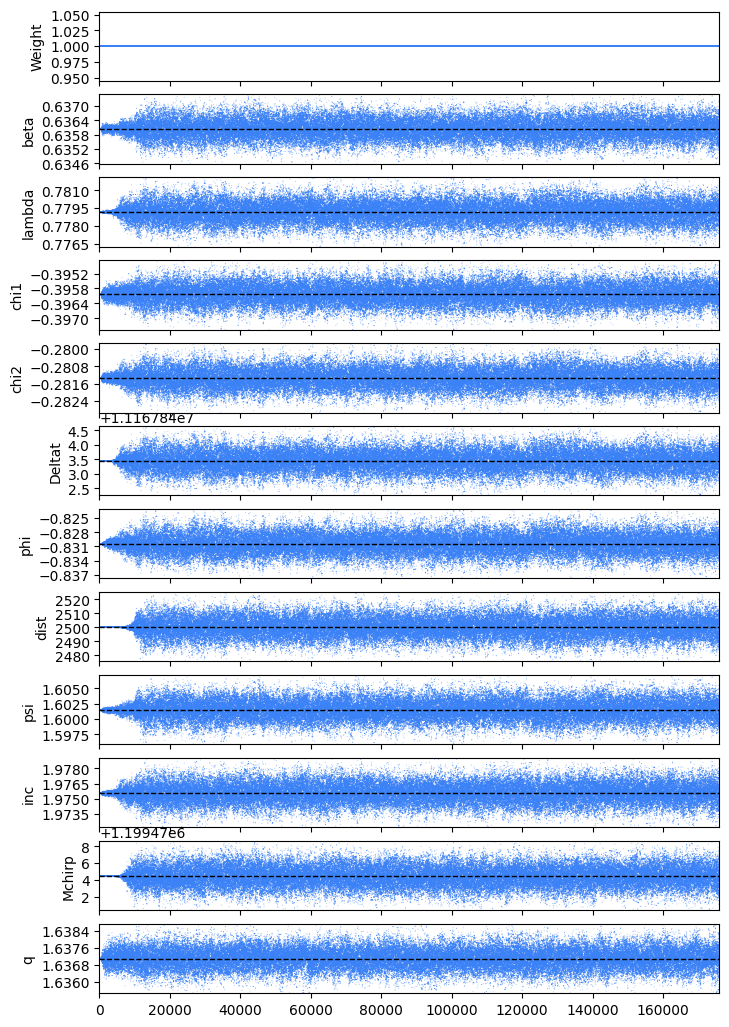

In [310]:
c = ChainConsumer()

samples_2ch = sampler.get_chain()["mbh"][:, 0].reshape(-1, 11)

dfs_2chnls = pd.DataFrame(samples_2ch[burn:, :], columns = keys)

c.add_chain(Chain(samples=dfs_2chnls, name="noiseless", color="blue"))
c.add_truth(Truth(location={k:v for (k,v) in zip(labels_final,truths)}))

c.plotter.plot()
c.plotter.plot_walks()

In [311]:
csv_filename_0mm = "0mm_"+ save_name + "_chains.csv"
dfs_2chnls.to_csv(csv_filename_0mm, index=False)
print(f"Chain data saved to {csv_filename_0mm}")

Chain data saved to 0mm_sangria_index_2_distance2500_chains.csv


# Add 1mm noise to the waveform

In [312]:
#generate noise psd for 1mm
psd_sqrt = (6e-11*(np.sin(2*fvec_masked/fstar)**2) + 1e-12)/2.5e9 #2.5e9 is armlength
#1mm eyeball -> 6e-11
#2mm eyeball -> 2e-10
#psd = ((6e-11*(np.sin(2*fvec/fstar)**2) + 1e-12)/2.5e9)**2/(df*4)

#Add noise function
def randc(r):
    #fix seed
    np.random.seed(42)
    return r/np.sqrt(2)*(np.random.rand(*r.shape) + 1j*np.random.rand(*r.shape))

def randE(r):
    #fix seed
    np.random.seed(24)
    return r/np.sqrt(2)*(np.random.rand(*r.shape) + 1j*np.random.rand(*r.shape))


In [313]:

#generate noise
noise_fft_A_1 = randc(psd_sqrt)
noise_fft_A = randc(psd_sqrt)
noise_fft_E_1 = randE(psd_sqrt)
noise_fft_E = randE(psd_sqrt)

#add noisy noise to signal
Afull = A_full+ noise_fft_A/np.sqrt(df*4)
Efull = E_full+ noise_fft_E/np.sqrt(df*4)

A_full_1 = Afull
E_full_1 = Efull

In [314]:
DA = Afull.copy()
DE = Efull.copy()

In [315]:
fig1, ax1 = plt.subplots()
ax1.loglog(fvec_masked, np.abs(A_full)**2, label = 'Afull, No TTL')
ax1.loglog(fvec_masked, np.abs(Afull)**2, label = 'Afull, TTL')
ax1.loglog(fvec_masked, Npsd_masked, '--', color = 'k', label = 'Npsd')
#ax1.loglog(fvec, psd, color = 'silver' ,label = 'TTL psd')
ax1.set_xlabel('Frequency')
ax1.set_ylabel('PSD')
ax1.legend(loc = 'lower center')
ax1.grid()

# Rerun the same MCMC with 1mm

In [316]:
sampler2 = EnsembleSampler(
    nwalkers,
    ndims,
    likelihood_interp,
    priors,
    args=(),
    branch_names=["mbh"],
    tempering_kwargs=dict(ntemps=ntemps),
    nleaves_max=dict(mbh=1),
)

In [317]:
sampler2.run_mcmc(start_state, nsamples, progress=True, store = True)

100%|██████████| 8000/8000 [5:49:32<00:00,  2.62s/it]  


# Plot walkers and corners 1mm

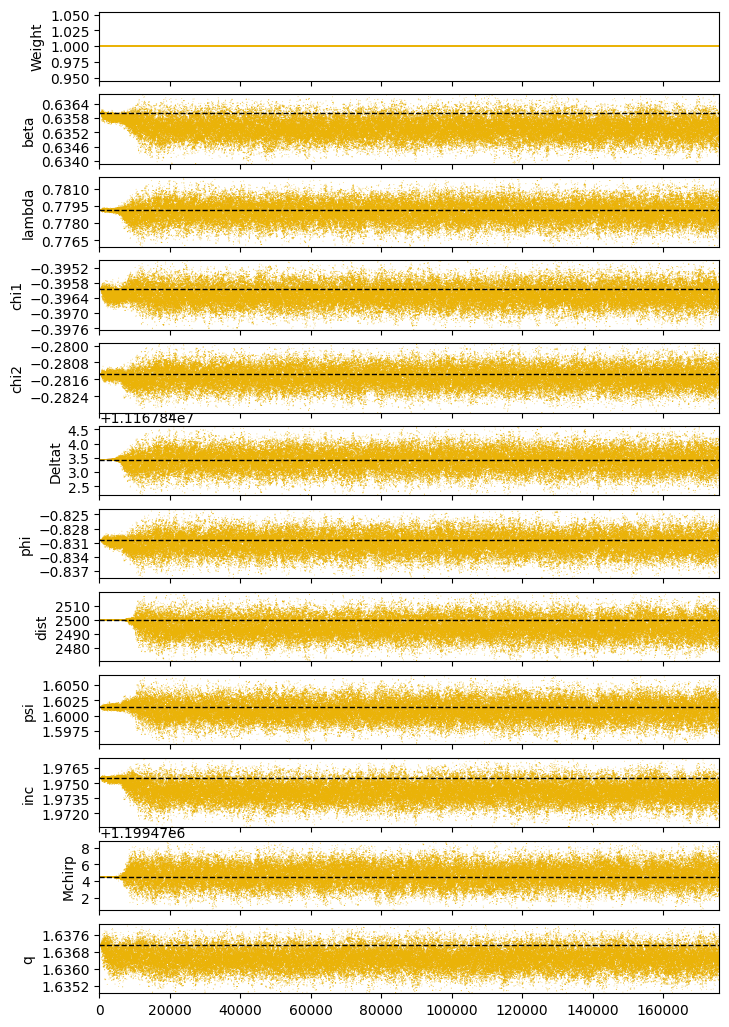

In [318]:
a = ChainConsumer()

one_samples = sampler2.get_chain()["mbh"][:, 0].reshape(-1, 11)

#burn = 30000
one_samp= pd.DataFrame(one_samples[burn:, :], columns = keys)

a.add_chain(Chain(samples=one_samp, name="1mm", color="yellow"))
a.add_truth(Truth(location={k:v for (k,v) in zip(labels_final,truths)}))

a.plotter.plot()
a.plotter.plot_walks()

In [319]:
csv_filename_1mm = "1mm_"+ save_name + "_chains.csv"
one_samp.to_csv(csv_filename_1mm, index=False)
print(f"Chain data saved to {csv_filename_1mm}")

Chain data saved to 1mm_sangria_index_2_distance2500_chains.csv


# Add 2mm noise to the waveform

In [320]:
#generate noise psd for 1mm
psd_sqrt = (2e-10*(np.sin(2*fvec_masked/fstar)**2) + 1e-12)/2.5e9 #2.5e9 is armlength
#1mm eyeball -> 6e-11
#2mm eyeball -> 2e-10

noise_fft_A_2 = randc(psd_sqrt)
noise_fft_A = randc(psd_sqrt)
noise_fft_E_2 = randE(psd_sqrt)
noise_fft_E = randE(psd_sqrt)

#add noisy noise to signal
Afull = A_full+ noise_fft_A/np.sqrt(df*4)
Efull = E_full+ noise_fft_E/np.sqrt(df*4)

A_full_2 = Afull
E_full_2 = Efull

In [321]:
fig2, ax2 = plt.subplots()
ax2.loglog(fvec_masked, np.abs(Afull)**2, label = 'Afull, 2.3 TTL')
ax2.loglog(fvec_masked, np.abs(A_full_1)**2, label = 'Afull, 1 TTL')
ax2.loglog(fvec_masked, np.abs(A_full)**2, label = 'A_full, no TTL')
ax2.loglog(fvec_masked, np.abs(noise_fft_A/np.sqrt(df*4))**2, label = 'noise_fft_A')
ax2.loglog(fvec_masked, Npsd_masked/(df*4), '--', color = 'k', label = 'Npsd')
ax2.set_xlabel('Frequency')
ax2.set_ylabel('PSD')
ax2.legend(loc = 'upper left')
ax2.grid()

In [322]:
DA = Afull.copy()
DE = Efull.copy()

# Rerun the same MCMC with 2.3 mm

In [323]:
sampler3 = EnsembleSampler(
    nwalkers,
    ndims,
    likelihood_interp,
    priors,
    args=(),
    branch_names=["mbh"],
    tempering_kwargs=dict(ntemps=ntemps),
    nleaves_max=dict(mbh=1),
)

In [324]:
sampler3.run_mcmc(start_state, nsamples, progress=True, store = True)

100%|██████████| 8000/8000 [5:57:54<00:00,  2.68s/it]  


# Corners and Chains for 2.3 mm

In [325]:
#define truths
keys = src0.keys()
labels = list(keys)

inj=np.array(list(src0.values()))

truths = inj.flatten()
labels_final = labels

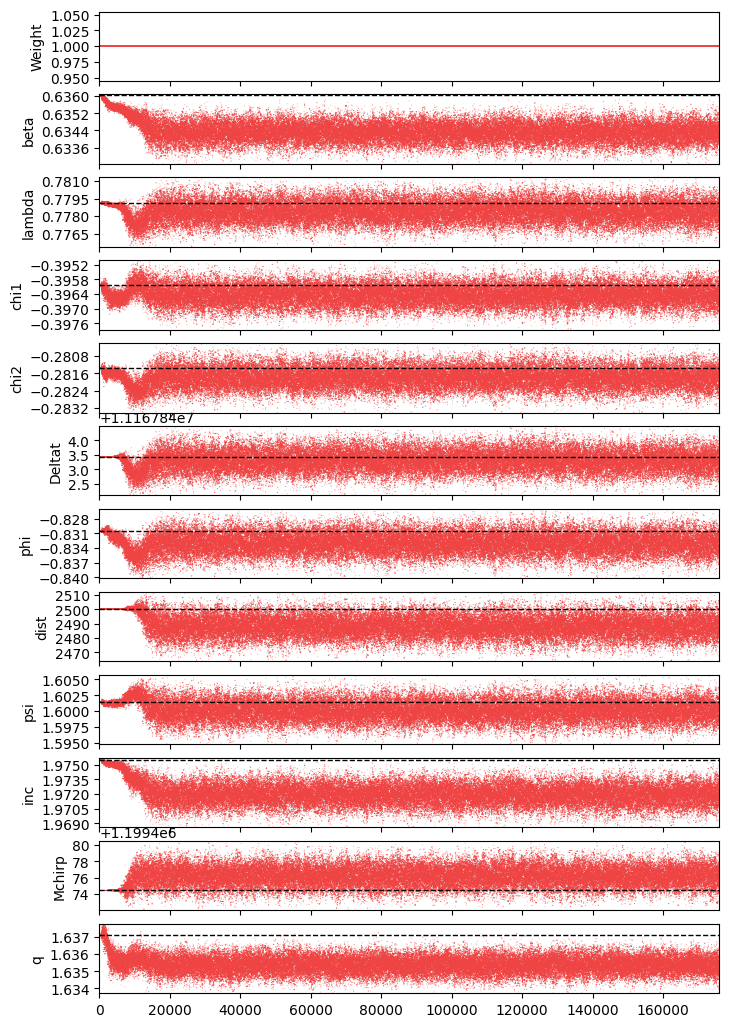

In [326]:
b = ChainConsumer()
burn = 0000
two_samples = sampler3.get_chain()["mbh"][:, 0].reshape(-1, 11)

#burn = 800000
two_samp= pd.DataFrame(two_samples[burn:, :], columns = keys)

b.add_chain(Chain(samples=two_samp, name="2.3 mm/rad", color="red"))
b.add_truth(Truth(location={k:v for (k,v) in zip(labels_final,truths)}))

b.plotter.plot()
b.plotter.plot_walks()

In [327]:
'''
log = ChainConsumer()
loglik = sampler3.get_log_like()#["mbh"][:, 0].reshape(-1, 11)
loglik = loglik[:, 0]
loglik = pd.DataFrame(loglik, columns = keys)
print(loglik.shape)
log.add_chain(Chain(samples=loglik, name="log likelihood 2.3", color="red"))
log.plotter.plot_walks()
'''

'\nlog = ChainConsumer()\nloglik = sampler3.get_log_like()#["mbh"][:, 0].reshape(-1, 11)\nloglik = loglik[:, 0]\nloglik = pd.DataFrame(loglik, columns = keys)\nprint(loglik.shape)\nlog.add_chain(Chain(samples=loglik, name="log likelihood 2.3", color="red"))\nlog.plotter.plot_walks()\n'

In [328]:
csv_filename_2mm = "2mm_"+ save_name + "_chains.csv"
two_samp.to_csv(csv_filename_2mm, index=False)
print(f"Chain data saved to {csv_filename_2mm}")

Chain data saved to 2mm_sangria_index_2_distance2500_chains.csv


# Let'd do a small checkin with those three chains

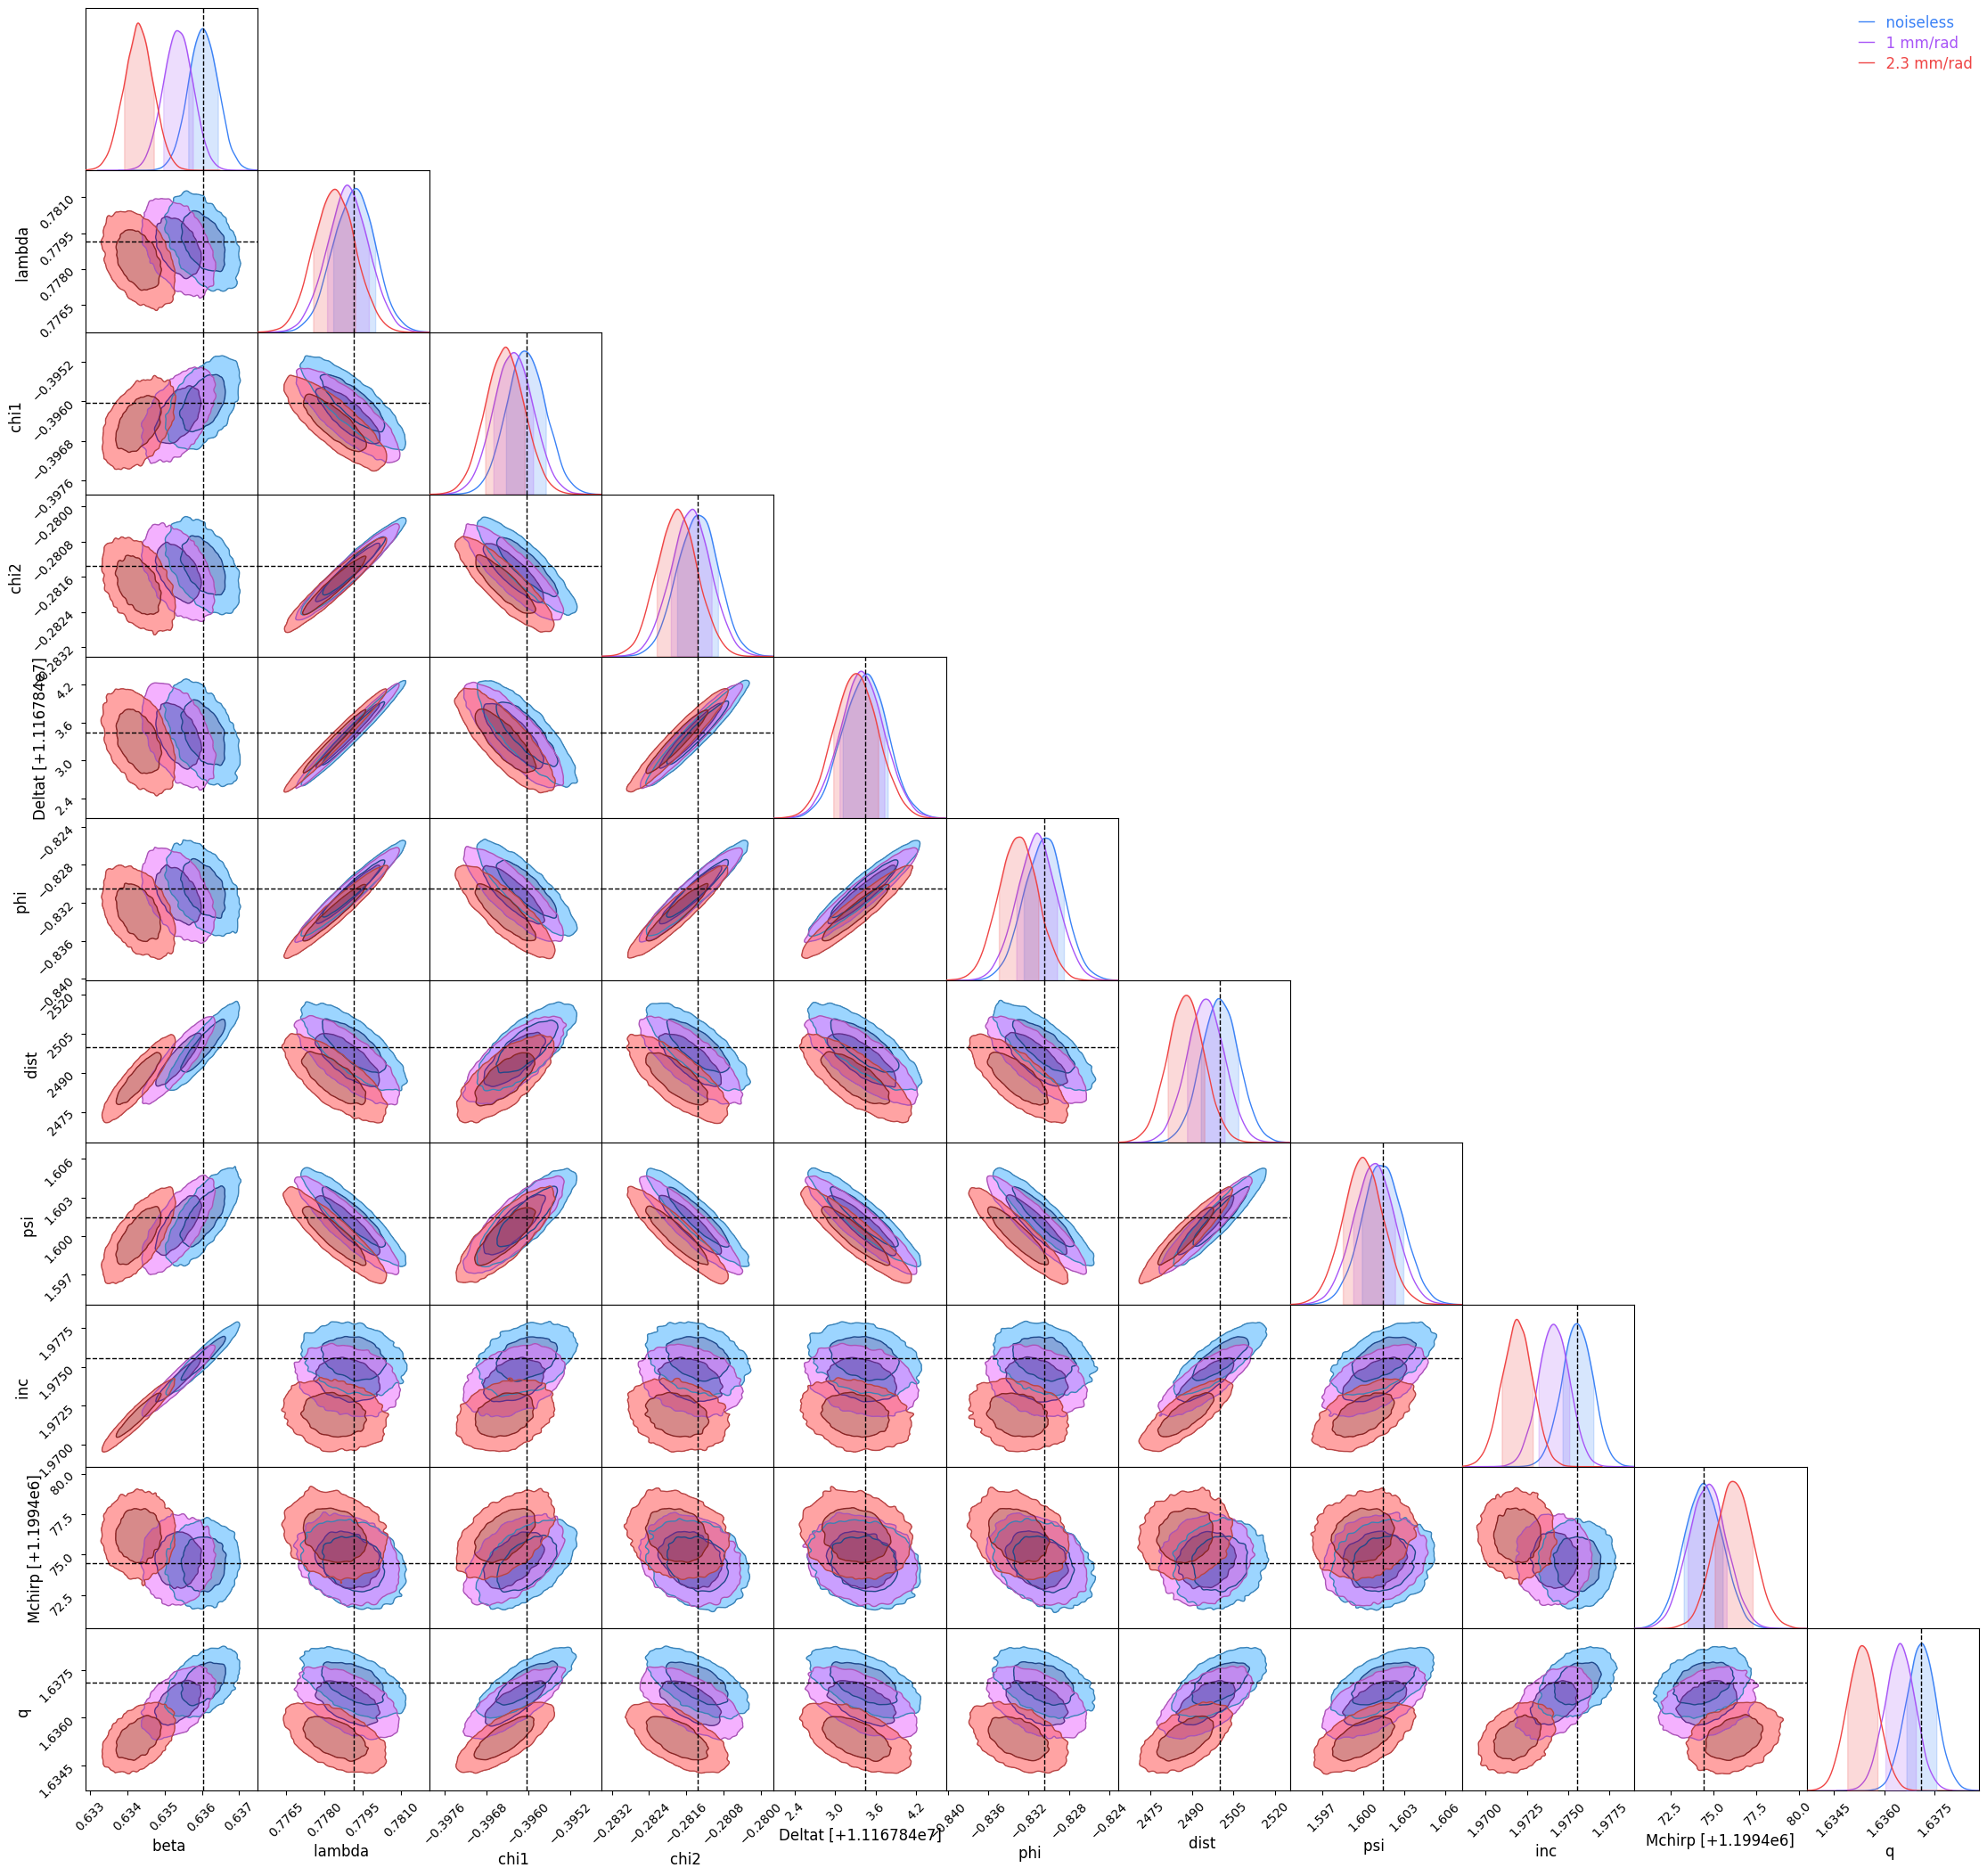

In [329]:
check = ChainConsumer()
burn = 60000
check.add_chain(Chain(samples=dfs_2chnls[burn:], name="noiseless", color="blue"))
check.add_chain(Chain(samples=one_samp[burn:], name="1 mm/rad", color="purple"))
check.add_chain(Chain(samples=two_samp[burn:], name="2.3 mm/rad", color="red"))
check.add_truth(Truth(location={k:v for (k,v) in zip(labels_final,truths)}))

check.plotter.plot()
#check.plotter.plot_walks()

# Checking noise realization

In [331]:
def likelihood_interp_trial(pvector):
    src = {k: v for k, v in zip(keys, pvector)}

    tdisignal = lisa.GenerateLISATDISignal_SMBH(src, 
                                                gridfreq=fvec, 
                                                #scale_freq_hm=False,
                                                **waveform_params_smbh)
    modesf = tdisignal['tdi']['modes']

    df = fvec[1]-fvec[0]

    hA = np.zeros(len(fvec), dtype=complex)
    hE = np.zeros(len(fvec), dtype=complex)

    for i in range(len(modesf)):
        mbh_lb = tdisignal['tdi'][modesf[i]]

        mask = (fvec >= mbh_lb['freq'].min()) & (fvec <= mbh_lb['freq'].max())
        
        #phase
        splPh = spline(mbh_lb['freq'], mbh_lb['phase'], ext='raise')
        #A
        splAr = spline(mbh_lb['freq'], mbh_lb['amp_real_chan1'])
        splAi = spline(mbh_lb['freq'], mbh_lb['amp_imag_chan1'])
        #E
        splEr = spline(mbh_lb['freq'], mbh_lb['amp_real_chan2'])
        splEi = spline(mbh_lb['freq'], mbh_lb['amp_imag_chan2'])

        A_partial = np.conjugate((splAr(fvec[mask]) + 1.j*splAi(fvec[mask])) * np.exp(1j*splPh(fvec[mask])))
        E_partial = np.conjugate((splEr(fvec[mask]) + 1.j*splEi(fvec[mask])) * np.exp(1j*splPh(fvec[mask])))

        hA[mask] += A_partial
        hE[mask] += E_partial

    hA = hA[n0:-n1]
    hE = hE[n0:-n1]

    SN_m = 4.0 * df * np.sum(np.real(DA * np.conjugate(hA)) / Npsd_masked) + 4.0 * df * np.sum(np.real(DE * np.conjugate(hE)) / Npsd_masked)

    XX = 4.0 * df * np.sum(np.abs(hA)**2 / Npsd_masked) + 4.0 * df * np.sum(np.abs(hE)**2 / Npsd_masked)

    loglik = SN_m - 0.5 * XX

    return loglik, hA

In [335]:
log, atrial = likelihood_interp_trial(np.array(list(src0.values())))

figmm, axmm = plt.subplots()
#axmm.loglog(fvec_masked, np.abs(A_full)**2, label = 'noiseless')
axmm.loglog(fvec_masked, np.abs(noise_fft_E_1)**2, '-.', label = 'E 1mm')
axmm.loglog(fvec_masked, np.abs(noise_fft_E_2)**2, '-.', label = 'E 2.3mm')
axmm.loglog(fvec_masked, np.abs(noise_fft_A_1)**2, label = 'A 1mm')
axmm.loglog(fvec_masked, np.abs(noise_fft_A_2)**2, label = 'A 2.3mm')
axmm.set_xlim([.01, 0.1])
#axmm.set_ylim([10**-43, 10**-36])
axmm.legend()